# XGBoost Model v3b
### Key changes vs v3a:
- **OOF ensemble prediction** — final predictions average all 15 fold models (more stable, better AUC)
- **Threshold from ES set** — optimal threshold found on early-stop held-out set, not normalised OOF
- **Consistent eval metric** — CV folds now use `aucpr` for early stopping (matches Optuna)
- **`max_bin=512`** added for finer splits with `hist` tree method
- **Reduced `scale_pos_weight` ceiling** from 4× to 2× imbalance ratio to avoid over-weighting positives


In [5]:
import pandas as pd
import numpy as np
import zipfile, warnings
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

Imports OK


## Feature Engineering (leakage-safe)

In [6]:
TOTAL_ITEMS = 1000

def compute_item_stats(XX_train):

    item_avg = XX_train.groupby('item')['rating'].mean().rename('item_avg_rating')
    item_pop = XX_train.groupby('item')['user'].count().rename('item_popularity')
    return item_avg, item_pop


def build_features(XX_input, item_avg=None, item_pop=None):
    """
    Build user-level features.
    Always pass item_avg + item_pop from training when processing test data.
    """
    if item_avg is None:
        item_avg = XX_input.groupby('item')['rating'].mean().rename('item_avg_rating')
    if item_pop is None:
        item_pop = XX_input.groupby('item')['user'].count().rename('item_popularity')

    # Basic rating stats
    stats = XX_input.groupby('user')['rating'].agg(
        rating_mean='mean', rating_std='std', rating_median='median',
        rating_min='min',   rating_max='max', rating_count='count'
    )
    stats['rating_std']   = stats['rating_std'].fillna(0)
    stats['rating_range'] = stats['rating_max'] - stats['rating_min']

    # Rating proportions + entropy
    rdist  = XX_input.groupby(['user', 'rating']).size().unstack(fill_value=0)
    rdist  = rdist.reindex(columns=range(6), fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f'prop_rating_{i}' for i in range(6)]
    stats['rating_entropy'] = rprops.apply(lambda r: entropy(r[r > 0]), axis=1)
    stats = stats.join(rprops)

    # Extreme rating proportions (new v2)
    stats['prop_extreme'] = rprops['prop_rating_0'] + rprops['prop_rating_5']
    stats['prop_zero']    = rprops['prop_rating_0']
    stats['prop_five']    = rprops['prop_rating_5']

    # Item coverage (new v2)
    stats['unique_items_rated']  = XX_input.groupby('user')['item'].nunique()
    stats['item_coverage_ratio'] = stats['unique_items_rated'] / TOTAL_ITEMS

    # Item popularity (frozen)
    XX_pop = XX_input.merge(item_pop, left_on='item', right_index=True)
    pop_f  = XX_pop.groupby('user')['item_popularity'].agg(
        avg_item_popularity='mean', std_item_popularity='std'
    )
    pop_f['std_item_popularity'] = pop_f['std_item_popularity'].fillna(0)
    stats = stats.join(pop_f)

    # Deviation from item average (frozen)
    XX_dev = XX_input.merge(item_avg, left_on='item', right_index=True)
    XX_dev['deviation'] = XX_dev['rating'] - XX_dev['item_avg_rating']
    dev_f = XX_dev.groupby('user')['deviation'].agg(
        mean_deviation='mean', std_deviation='std',
        abs_mean_deviation=lambda x: np.mean(np.abs(x))
    )
    dev_f['std_deviation'] = dev_f['std_deviation'].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby('user')['item_avg_rating'].agg(
        avg_item_avg_rating='mean', std_item_avg_rating='std'
    )
    iqf['std_item_avg_rating'] = iqf['std_item_avg_rating'].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

print('Feature builder defined.')

Feature builder defined.


## Load Data + Build Features

In [7]:
data   = np.load('training_batch_with_labels.npz')
XX_all = pd.DataFrame(data['X'], columns=['user', 'item', 'rating'])
yy_all = pd.DataFrame(data['y'], columns=['user', 'label'])


item_avg, item_pop = compute_item_stats(XX_all)
train_feats = build_features(XX_all, item_avg=item_avg, item_pop=item_pop).merge(yy_all, on='user')

feature_cols = [c for c in train_feats.columns if c not in ['user', 'label']]

X_trainval   = train_feats[feature_cols].values
y_trainval   = train_feats['label'].values

scaler       = RobustScaler()
X_trainval_s = scaler.fit_transform(X_trainval)

print(f'Training users: {len(y_trainval)}')
print(f'Features:       {len(feature_cols)}')


Training users: 1100
Features:       26


## Optuna Hyperparameter Search (200 trials)

In [8]:
spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)

def objective(trial):
    # Choose grow policy first, as it affects which depth param to use
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])

    params = dict(
        n_estimators       = trial.suggest_int('n_estimators', 100, 3000),
        learning_rate      = trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        subsample          = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree   = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        colsample_bylevel  = trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        colsample_bynode   = trial.suggest_float('colsample_bynode', 0.4, 1.0),
        min_child_weight   = trial.suggest_int('min_child_weight', 1, 10),
        gamma              = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha          = trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        reg_lambda         = trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        max_delta_step     = trial.suggest_int('max_delta_step', 0, 10),
        scale_pos_weight   = trial.suggest_float('scale_pos_weight',
                                                  spw_global * 0.5, spw_global * 2.0),
        grow_policy        = grow_policy,
    )

    # lossguide uses max_leaves; depthwise uses max_depth
    if grow_policy == 'lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 512)
    else:
        params['max_depth'] = trial.suggest_int('max_depth', 3, 10)

    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    aucs = []
    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params, eval_metric='aucpr', early_stopping_rounds=50,
            random_state=42, n_jobs=-1, tree_method='hist'
        )
        m.fit(X_trainval_s[tr_i], y_trainval[tr_i],
              eval_set=[(X_trainval_s[val_i], y_trainval[val_i])], verbose=False)
        aucs.append(roc_auc_score(y_trainval[val_i],
                                   m.predict_proba(X_trainval_s[val_i])[:, 1]))
    return np.mean(aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

best_params = study.best_params
print(f'Best CV AUC: {study.best_value:.4f}')
print('Best params:', best_params)

Best trial: 130. Best value: 0.935375: 100%|██████████| 200/200 [07:22<00:00,  2.21s/it]

Best CV AUC: 0.9354
Best params: {'grow_policy': 'lossguide', 'n_estimators': 2845, 'learning_rate': 0.020769311559350113, 'subsample': 0.9037516477316319, 'colsample_bytree': 0.8303912575880006, 'colsample_bylevel': 0.9585262392223752, 'colsample_bynode': 0.7488848781805113, 'min_child_weight': 2, 'gamma': 0.7439596620568051, 'reg_alpha': 0.002193742108418679, 'reg_lambda': 0.0013451405375186404, 'max_delta_step': 3, 'scale_pos_weight': 14.771360762825536, 'max_leaves': 258}


## 10-Fold CV with Best Params

In [9]:
from sklearn.model_selection import StratifiedKFold
skf        = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
aucs_cv    = []
oof_scores = np.zeros(len(X_trainval_s))
fold_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval_s, y_trainval)):
    X_tr, X_val = X_trainval_s[tr_idx], X_trainval_s[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    m = xgb.XGBClassifier(
        **best_params, eval_metric='aucpr', early_stopping_rounds=50,
        max_bin=512,
        random_state=42, n_jobs=-1, tree_method='hist'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    p_val = m.predict_proba(X_val)[:, 1]
    oof_scores[val_idx] = p_val
    fold_models.append(m)
    auc = roc_auc_score(y_val, p_val)
    aucs_cv.append(auc)
    print(f'Fold {fold+1}:  XGB={auc:.4f}')

oof_auc = roc_auc_score(y_trainval, oof_scores)
print(f'\n=== CV Results ===')
print(f'XGBoost  AUC: {np.mean(aucs_cv):.4f} ± {np.std(aucs_cv):.4f}')
print(f'OOF AUC:      {oof_auc:.4f}')

Fold 1:  XGB=0.9595
Fold 2:  XGB=0.8977
Fold 3:  XGB=0.8038
Fold 4:  XGB=0.8998
Fold 5:  XGB=0.9424
Fold 6:  XGB=0.9988
Fold 7:  XGB=0.9602
Fold 8:  XGB=0.9030
Fold 9:  XGB=1.0000
Fold 10:  XGB=0.8632
Fold 11:  XGB=0.8874
Fold 12:  XGB=0.9762
Fold 13:  XGB=0.9719
Fold 14:  XGB=0.8030
Fold 15:  XGB=0.9924

=== CV Results ===
XGBoost  AUC: 0.9240 ± 0.0631
OOF AUC:      0.8529


## Final Model + Evaluation

In [10]:
# ── Train a final model on 90% for threshold calibration ────────────────────────────
X_ft, X_es, y_ft, y_es = train_test_split(
    X_trainval_s, y_trainval, test_size=0.15, stratify=y_trainval, random_state=42
)
final_model = xgb.XGBClassifier(
    **best_params, eval_metric='aucpr', early_stopping_rounds=50,
    max_bin=512,
    random_state=42, n_jobs=-1, tree_method='hist'
)
final_model.fit(X_ft, y_ft, eval_set=[(X_es, y_es)], verbose=False)

# ── Pick threshold on the early-stop held-out set (not OOF) ─────────────────────────
p_es = final_model.predict_proba(X_es)[:, 1]

thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (p_es >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_es == 1))
    tn = np.sum((preds_t == 0) & (y_es == 0))
    fp = np.sum((preds_t == 1) & (y_es == 0))
    fn = np.sum((preds_t == 0) & (y_es == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)
print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

# Use Youden's J threshold (better balance for AUC-aligned threshold)
best_threshold = thresholds[best_j_idx]
print(f"\nUsing Youden's J threshold: {best_threshold:.3f}")

Optimal threshold — Youden's J : 0.532  (prec=0.484, rec=1.000)
Optimal threshold — Best F1   : 0.623  (prec=0.917, rec=0.733)

Using Youden's J threshold: 0.532


## Feature Importance

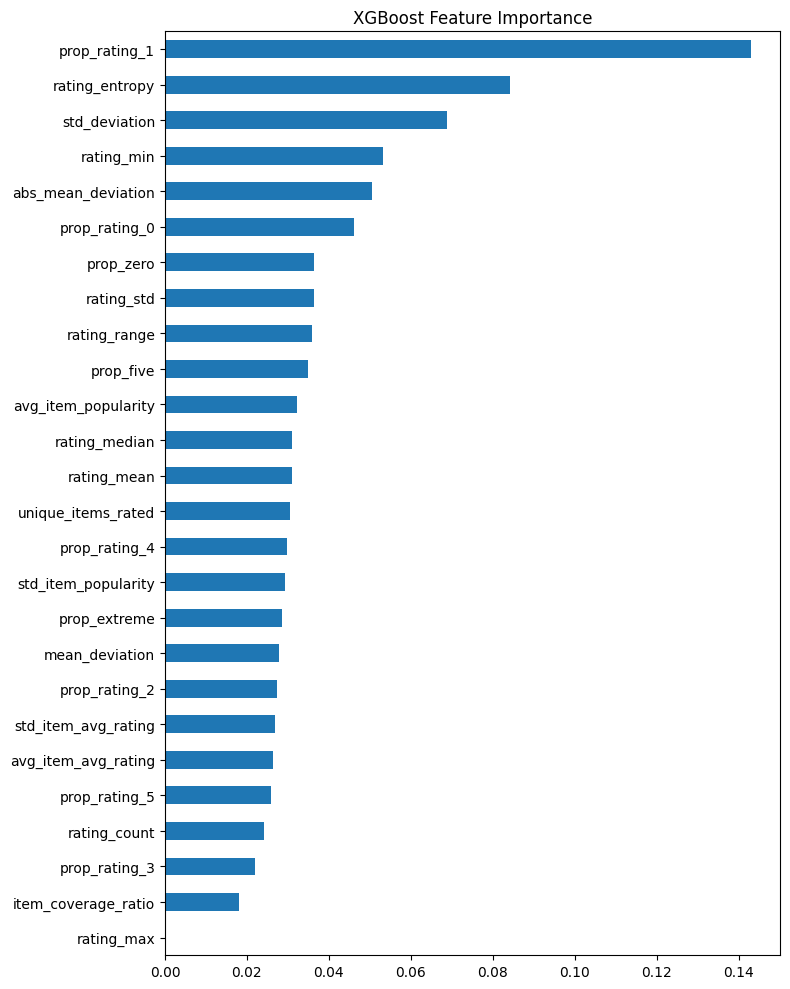

Top 10 features:
prop_rating_1         0.142941
rating_entropy        0.084155
std_deviation         0.068784
rating_min            0.053198
abs_mean_deviation    0.050580
prop_rating_0         0.046173
prop_zero             0.036488
rating_std            0.036431
rating_range          0.035946
prop_five             0.034797
dtype: float32


In [11]:
feat_imp = pd.Series(final_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()
print('Top 10 features:')
print(feat_imp.head(10))

## Build Test Features + Submit

In [12]:
# Load unlabelled prediction data
pred_data   = np.load('first_batch.npz')
XX_pred_raw = pd.DataFrame(pred_data['X'], columns=['user', 'item', 'rating'])

# Build features using FROZEN item stats from training (leakage-safe)
pred_feats = build_features(XX_pred_raw, item_avg=item_avg, item_pop=item_pop)

# ── Sort by user ID so predictions are in the order Codabench expects ──
pred_feats = pred_feats.sort_values('user').reset_index(drop=True)

# Scale
X_pred_s = scaler.transform(pred_feats[feature_cols].values)

# ── Ensemble: average probabilities across all 15 fold models ──
fold_preds = np.column_stack([m.predict_proba(X_pred_s)[:, 1] for m in fold_models])
y_score    = fold_preds.mean(axis=1)

# Normalise to [0, 1]
y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min())

# Save submission
np.savez('submission.npz', predictions=y_score_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')
pd.DataFrame({'predictions': y_score_norm}).to_csv('submission.csv', index=False)

print(f'Users predicted: {pred_feats["user"].nunique()}')
print(f'First 5 user IDs: {pred_feats["user"].values[:5]}')  # should be 2500, 2501...
print('submission.zip ready for Codabench')

Users predicted: 1100
First 5 user IDs: [2500 2501 2502 2503 2504]
submission.zip ready for Codabench



## ─── Scores (v3a baseline) ───────────────────────────
AUC:       0.8942
Precision: 0.6170
Recall:    0.5800
F1 Score:  0.5979

1:05am 3/16/2026
